# Chapter 4 - Model Evaluation

**Name:** Mohammad Fauzi Hadiwijaya  
**Course:** Machine Learning  
**Source Book:** Introduction to Machine Learning with Python

## Objectives
- Understand model evaluation
- Learn accuracy, precision, recall
- Learn confusion matrix
- Learn cross validation

## What is Model Evaluation?

Model evaluation is the process of measuring how well a machine learning model performs on unseen data.

It helps determine whether the model is reliable or not.

## Common Metrics

### 1. Accuracy
Percentage of correct predictions.

### 2. Precision
How many predicted positives are actually positive.

### 3. Recall
How many actual positives are correctly detected.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [3]:
# Build model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

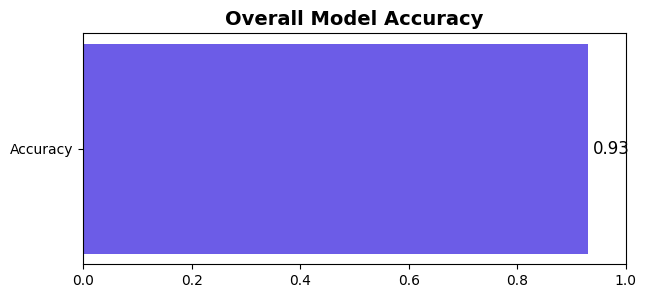

In [4]:
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(7,3))
plt.barh(["Accuracy"], [acc], color="#6C5CE7")

plt.xlim(0,1)
plt.title("Overall Model Accuracy", fontsize=14, weight="bold")
plt.text(acc+0.01, 0, round(acc,2), va="center", fontsize=12)

plt.show()

### Interpretation

The model correctly predicts approximately 93% of unseen test data, indicating strong overall performance.

## Confusion Matrix
Shows correct and incorrect predictions.

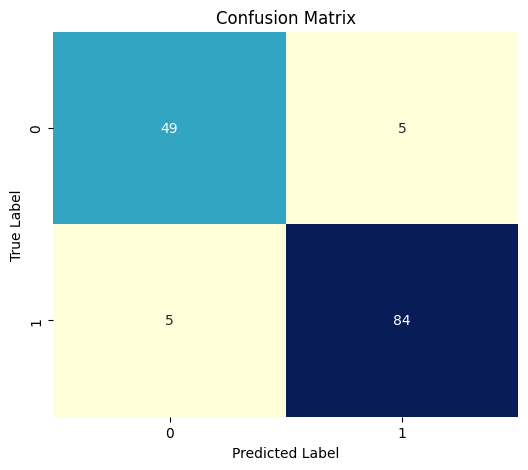

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Interpretation

Most predictions lie on the diagonal cells, meaning the majority of classifications are correct.

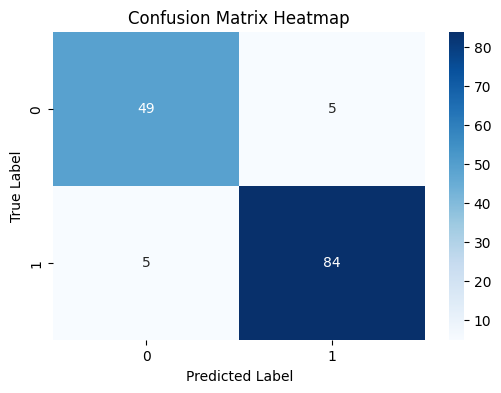

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")

plt.show()

/tmp/ipykernel_903/3357162772.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


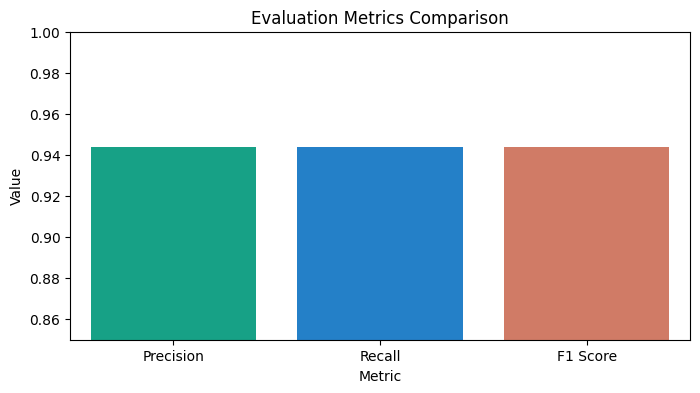

In [7]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric":["Precision","Recall","F1 Score"],
    "Value":[precision, recall, f1]
})

plt.figure(figsize=(8,4))

sns.barplot(
    data=metrics,
    x="Metric",
    y="Value",
    palette=["#00B894","#0984E3","#E17055"]
)

plt.ylim(0.85,1.0)
plt.title("Evaluation Metrics Comparison")

plt.show()

### Insight

All three metrics are high, which means the model is balanced and reliable.

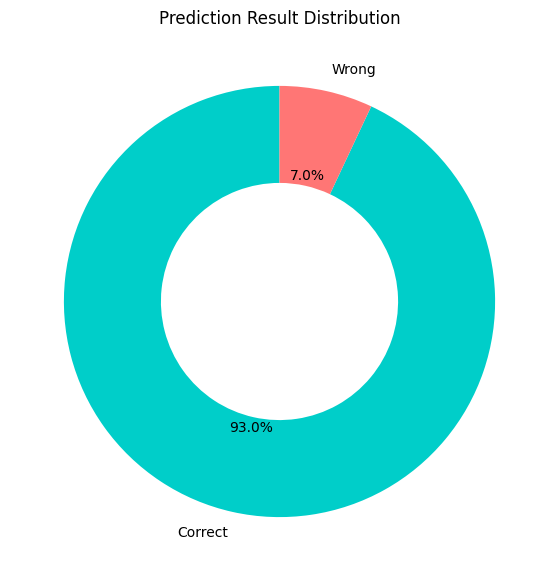

In [8]:
correct = (y_test == y_pred).sum()
wrong = (y_test != y_pred).sum()

plt.figure(figsize=(7,7))

plt.pie(
    [correct, wrong],
    labels=["Correct","Wrong"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#00CEC9","#FF7675"],
    wedgeprops={"width":0.45}
)

plt.title("Prediction Result Distribution")
plt.show()

## Interpretation

- High accuracy means many correct predictions.
- Precision is important when false positives are costly.
- Recall is important when missing positive cases is dangerous.
- Most predictions are correct, while only a small portion are misclassified.

In [9]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        54
           1       0.94      0.94      0.94        89

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143



## Conclusion

- Model evaluation is necessary before deployment.
- Accuracy alone is not always enough.
- Use precision, recall, and confusion matrix for better analysis.